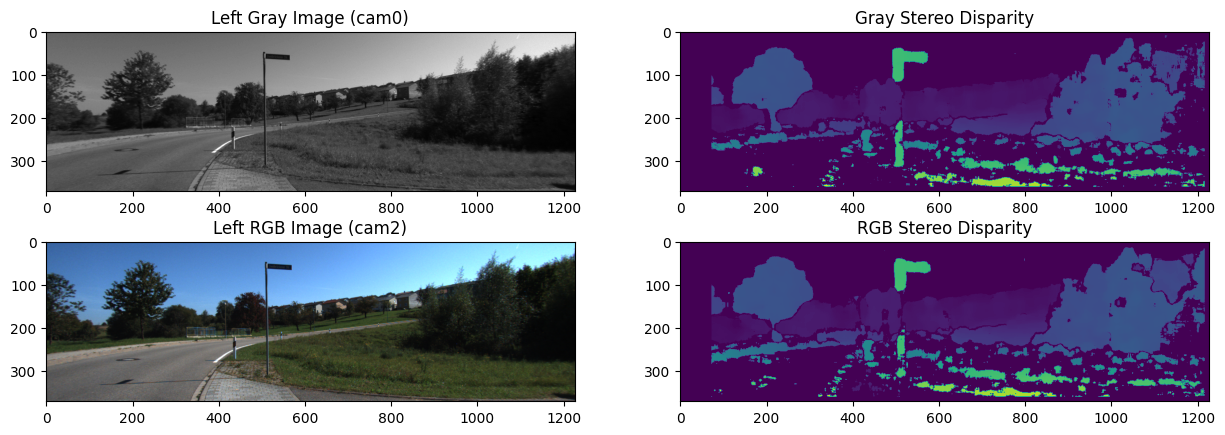

In [1]:
import pykitti
import cv2
import numpy as np
import matplotlib.pyplot as plt 

basedir = 'D:\\Research\\Dataset\\kitti_raw'

# Specify the dataset to load
date = '2011_09_30'
drive = '0034'

# Load the data. Optionally, specify the frame range to load.
dataset = pykitti.raw(basedir, date, drive,
                      frames=range(0, 20, 5))

# dataset.calib:         Calibration data are accessible as a named tuple
# dataset.timestamps:    Timestamps are parsed into a list of datetime objects
# dataset.oxts:          List of OXTS packets and 6-dof poses as named tuples
# dataset.camN:          Returns a generator that loads individual images from camera N
# dataset.get_camN(idx): Returns the image from camera N at idx
# dataset.gray:          Returns a generator that loads monochrome stereo pairs (cam0, cam1)
# dataset.get_gray(idx): Returns the monochrome stereo pair at idx
# dataset.rgb:           Returns a generator that loads RGB stereo pairs (cam2, cam3)
# dataset.get_rgb(idx):  Returns the RGB stereo pair at idx
# dataset.velo:          Returns a generator that loads velodyne scans as [x,y,z,reflectance]
# dataset.get_velo(idx): Returns the velodyne scan at idx

# Grab some data
first_gray = dataset.get_gray(0)
first_rgb = dataset.get_rgb(0)

# Do some stereo processing
stereo = cv2.StereoBM_create()
disp_gray = stereo.compute(np.array(first_gray[0]), np.array(first_gray[1]))
disp_rgb = stereo.compute(
    cv2.cvtColor(np.array(first_rgb[0]), cv2.COLOR_RGB2GRAY),
    cv2.cvtColor(np.array(first_rgb[1]), cv2.COLOR_RGB2GRAY))

# Display some data
f, ax = plt.subplots(2, 2, figsize=(15, 5))
ax[0, 0].imshow(first_gray[0], cmap='gray')
ax[0, 0].set_title('Left Gray Image (cam0)')

ax[0, 1].imshow(disp_gray, cmap='viridis')
ax[0, 1].set_title('Gray Stereo Disparity')

ax[1, 0].imshow(first_rgb[0])
ax[1, 0].set_title('Left RGB Image (cam2)')

ax[1, 1].imshow(disp_rgb, cmap='viridis')
ax[1, 1].set_title('RGB Stereo Disparity')

plt.show()

In [2]:
dataset.oxts

[OxtsData(packet=OxtsPacket(lat=48.97253396005, lon=8.4785980847297, alt=220.36932373047, roll=0.024535, pitch=-0.054499, yaw=-0.2732956732051, vn=-0.28616991631342, ve=1.0511593879403, vf=1.0893663084236, vl=-0.0025206644190083, vu=0.042070146255893, ax=2.068035372171, ay=0.3862744114195, az=9.7636036164337, af=1.5419331342146, al=0.15345466759833, au=9.8670055895041, wx=0.0071036291370239, wy=-0.01881922761832, wz=-0.098149373801969, wf=0.01238825663607, wl=-0.016456870264526, wu=-0.098055623973881, pos_accuracy=0.017804493814765, vel_accuracy=0.011313708498985, navstat=4, numsats=11, posmode=6, velmode=6, orimode=6), T_w_imu=array([[ 0.961457  ,  0.26853828, -0.05905608,  0.        ],
        [-0.26950553,  0.96295749, -0.00892414,  0.        ],
        [ 0.05447203,  0.02449612,  0.99821478,  0.        ],
        [ 0.        ,  0.        ,  0.        ,  1.        ]])),
 OxtsData(packet=OxtsPacket(lat=48.972531772959, lon=8.4786090271584, alt=220.40705871582, roll=0.027443, pitch=-0

In [6]:
dataset.get_velo(0).shape

(121184, 4)

Plotted frame 0
Plotted frame 1
Plotted frame 2
Plotted frame 3
Plotted frame 4
Plotted frame 5
Plotted frame 6
Plotted frame 7
Plotted frame 8
Plotted frame 9
Plotted frame 10
Plotted frame 11
Plotted frame 12
Plotted frame 13
Plotted frame 14
Plotted frame 15
Plotted frame 16
Plotted frame 17
Plotted frame 18
Plotted frame 19
Plotted frame 20
Plotted frame 21
Plotted frame 22
Plotted frame 23
Plotted frame 24
Plotted frame 25
Plotted frame 26
Plotted frame 27
Plotted frame 28
Plotted frame 29
Plotted frame 30
Plotted frame 31
Plotted frame 32
Plotted frame 33
Plotted frame 34
Plotted frame 35
Plotted frame 36
Plotted frame 37
Plotted frame 38
Plotted frame 39
Plotted frame 40
Plotted frame 41
Plotted frame 42
Plotted frame 43
Plotted frame 44
Plotted frame 45
Plotted frame 46
Plotted frame 47
Plotted frame 48
Plotted frame 49
Plotted frame 50
Plotted frame 51
Plotted frame 52
Plotted frame 53
Plotted frame 54
Plotted frame 55
Plotted frame 56
Plotted frame 57
Plotted frame 58
Plotted

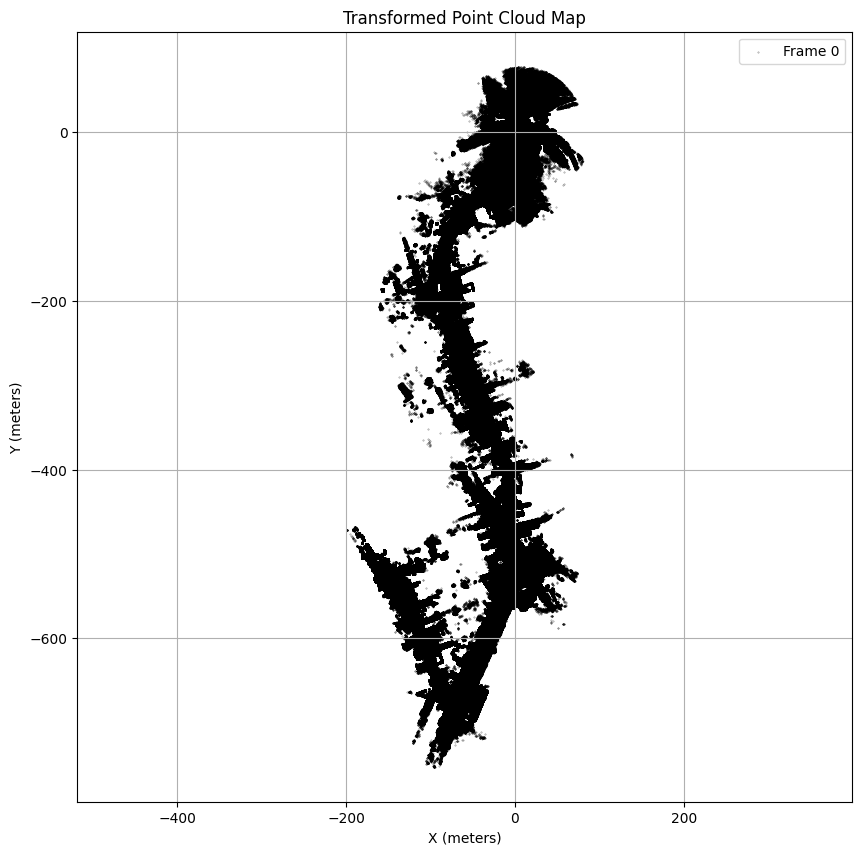

In [12]:
import pykitti
import numpy as np
import matplotlib.pyplot as plt

basedir = 'D:\\Research\\Dataset\\kitti_raw'
date = '2011_09_30'
drive = '0034'

# Load the KITTI dataset with the specified frame range
dataset = pykitti.raw(basedir, date, drive)

# Function to transform point cloud to global frame using T_w_imu
def transform_point_cloud(points, T_w_imu):
    # Append a row of ones to the points to use homogeneous coordinates
    points_homogeneous = np.hstack((points[:, :3], np.ones((points.shape[0], 1))))
    # Transform points to global frame
    points_global = (T_w_imu @ points_homogeneous.T).T
    return points_global[:, :3]  # Remove the homogeneous coordinate

# Set up plot for the aggregated top-down view
plt.figure(figsize=(10, 10))
plt.title('Transformed Point Cloud Map')
plt.xlabel('X (meters)')
plt.ylabel('Y (meters)')

# Aggregate and plot each frame's transformed point cloud
for idx, (oxts_data, velo_scan) in enumerate(zip(dataset.oxts, dataset.velo)):
    # Get the transformation matrix from the oxts data
    T_w_imu = oxts_data.T_w_imu
    
    # Transform point cloud to the global frame
    transformed_points = transform_point_cloud(velo_scan, T_w_imu)
    
    # Plot only the x and y coordinates for a top-down view
    plt.scatter(transformed_points[:, 0], transformed_points[:, 1], s=0.1, c='black', alpha=0.5, label=f'Frame {idx}' if idx == 0 else "")
    print(f'Plotted frame {idx}')

# Format the plot
plt.legend(loc='upper right')
plt.grid(True)
plt.axis('equal')
plt.show()


In [13]:
import pykitti

basedir = 'D:\\Research\\Dataset\\kitti_raw'
date = '2011_09_30'
drive = '0034'

# Load the KITTI dataset
dataset = pykitti.raw(basedir, date, drive)

# Collect latitude and longitude values from GPS data
latitudes = []
longitudes = []

# Extract GPS data for each frame
for oxts_data in dataset.oxts:
    latitudes.append(oxts_data.packet.lat)
    longitudes.append(oxts_data.packet.lon)

# Calculate the latitude and longitude range
lat_min, lat_max = min(latitudes), max(latitudes)
lon_min, lon_max = min(longitudes), max(longitudes)

print(f"Latitude range: {lat_min} to {lat_max}")
print(f"Longitude range: {lon_min} to {lon_max}")


Latitude range: 48.966459913885 to 48.97253396005
Longitude range: 8.4764446849301 to 8.4786640553283


<AxesSubplot:>

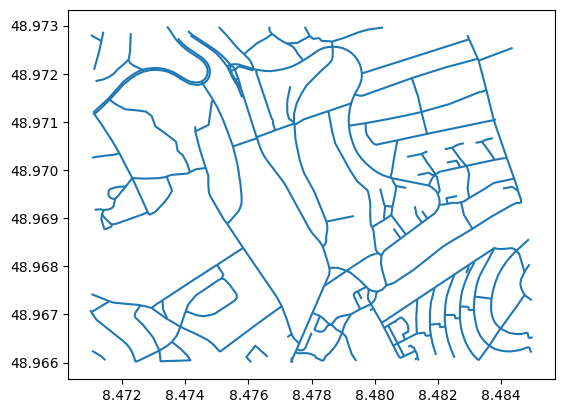

In [14]:
import geopandas as gpd 

osm_road = gpd.read_file('D:\\GitHub\\geo-localization-with-point-clouds-and-openstreetmap\\shape\\roads.shp')
osm_road.plot()

Plotted frame 0
Plotted frame 1
Plotted frame 2
Plotted frame 3
Plotted frame 4
Plotted frame 5
Plotted frame 6
Plotted frame 7
Plotted frame 8
Plotted frame 9
Plotted frame 10
Plotted frame 11
Plotted frame 12
Plotted frame 13
Plotted frame 14
Plotted frame 15
Plotted frame 16
Plotted frame 17
Plotted frame 18
Plotted frame 19
Plotted frame 20
Plotted frame 21
Plotted frame 22
Plotted frame 23
Plotted frame 24
Plotted frame 25
Plotted frame 26
Plotted frame 27
Plotted frame 28
Plotted frame 29
Plotted frame 30
Plotted frame 31
Plotted frame 32
Plotted frame 33
Plotted frame 34
Plotted frame 35
Plotted frame 36
Plotted frame 37
Plotted frame 38
Plotted frame 39
Plotted frame 40
Plotted frame 41
Plotted frame 42
Plotted frame 43
Plotted frame 44
Plotted frame 45
Plotted frame 46
Plotted frame 47
Plotted frame 48
Plotted frame 49
Plotted frame 50
Plotted frame 51
Plotted frame 52
Plotted frame 53
Plotted frame 54
Plotted frame 55
Plotted frame 56
Plotted frame 57
Plotted frame 58
Plotted

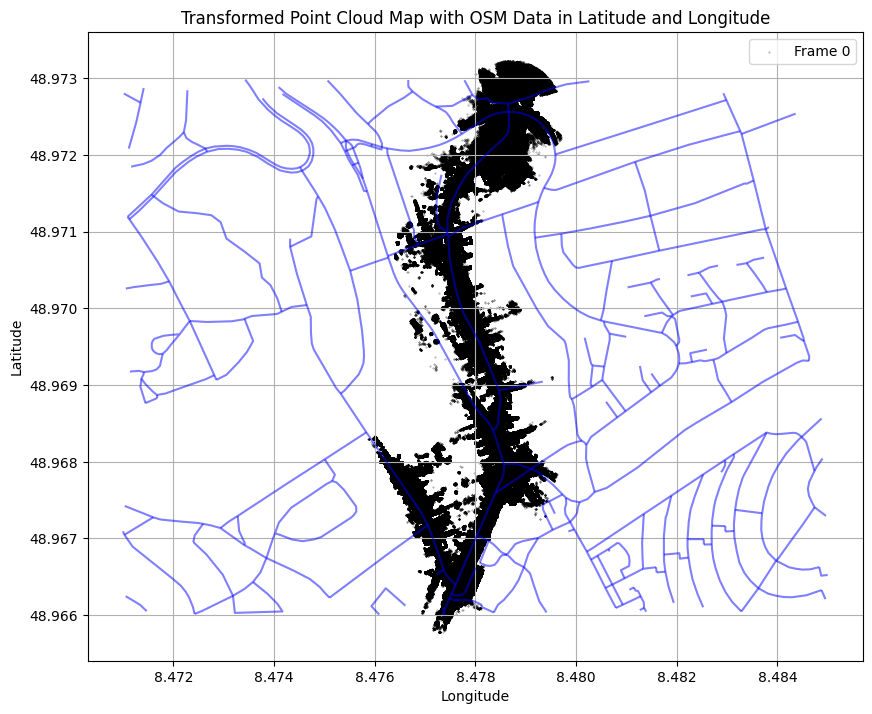

In [16]:
import pykitti
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
from pyproj import Transformer

basedir = 'D:\\Research\\Dataset\\kitti_raw'
date = '2011_09_30'
drive = '0034'

# Load the KITTI dataset
dataset = pykitti.raw(basedir, date, drive)

# Earth's radius in meters
earth_radius = 6378137.0

# Load the shapefile with OSM data using geopandas
osm_shapefile_path = 'D:\\GitHub\\geo-localization-with-point-clouds-and-openstreetmap\\shape\\roads.shp'
osm_data = gpd.read_file(osm_shapefile_path)

# Define the transformer for GPS (latitude, longitude) to global coordinates
transformer = Transformer.from_crs("epsg:4326", "epsg:4326", always_xy=True)

# Function to transform point cloud to latitude and longitude using the GPS origin
def transform_to_latlon(points, T_w_imu, origin_lat, origin_lon, origin_alt):
    # Translate and rotate points to the global frame
    points_homogeneous = np.hstack((points[:, :3], np.ones((points.shape[0], 1))))
    points_global = (T_w_imu @ points_homogeneous.T).T[:, :3]
    
    # Convert local X, Y, Z to latitude and longitude using ECEF conversion
    latitudes = []
    longitudes = []
    for x, y, z in points_global:
        delta_lat = y / earth_radius
        delta_lon = x / (earth_radius * np.cos(np.radians(origin_lat)))
        latitudes.append(origin_lat + np.degrees(delta_lat))
        longitudes.append(origin_lon + np.degrees(delta_lon))
    
    return np.array(latitudes), np.array(longitudes)

# Set up plot for the aggregated view in lat/lon
plt.figure(figsize=(10, 10))
plt.title('Transformed Point Cloud Map with OSM Data in Latitude and Longitude')
plt.xlabel('Longitude')
plt.ylabel('Latitude')

# Get the initial latitude, longitude, and altitude as the reference
origin_lat = dataset.oxts[0].packet.lat
origin_lon = dataset.oxts[0].packet.lon
origin_alt = dataset.oxts[0].packet.alt

# Aggregate and plot each frame's transformed point cloud
for idx, (oxts_data, velo_scan) in enumerate(zip(dataset.oxts, dataset.velo)):
    T_w_imu = oxts_data.T_w_imu
    
    # Transform point cloud to latitude and longitude
    latitudes, longitudes = transform_to_latlon(velo_scan, T_w_imu, origin_lat, origin_lon, origin_alt)
    
    # Plot the latitude and longitude for a top-down view
    plt.scatter(longitudes, latitudes, s=0.1, c='black', alpha=0.5, label=f'Frame {idx}' if idx == 0 else "")
    print(f'Plotted frame {idx}')

# Plot the OSM data on top of the point cloud map
osm_data.plot(ax=plt.gca(), color='blue', alpha=0.5, edgecolor='black')

# Format the plot
plt.legend(loc='upper right')
plt.grid(True)
plt.show()


In [1]:
import pykitti
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
from pyproj import Transformer
from scipy.spatial import ConvexHull
from shapely.geometry import Polygon

basedir = 'D:\\Research\\Dataset\\kitti_raw'
date = '2011_09_30'
drive = '0034'

# Load the KITTI dataset
dataset = pykitti.raw(basedir, date, drive)

# Earth's radius in meters
earth_radius = 6378137.0

# Load the shapefile with OSM data using geopandas
osm_shapefile_path = 'D:\\GitHub\\geo-localization-with-point-clouds-and-openstreetmap\\shape\\roads.shp'
osm_data = gpd.read_file(osm_shapefile_path)

# Define the transformer for GPS (latitude, longitude) to global coordinates
transformer = Transformer.from_crs("epsg:4326", "epsg:4326", always_xy=True)

# Function to transform point cloud to latitude and longitude using the GPS origin
def transform_to_latlon(points, T_w_imu, origin_lat, origin_lon, origin_alt):
    # Translate and rotate points to the global frame
    points_homogeneous = np.hstack((points[:, :3], np.ones((points.shape[0], 1))))
    points_global = (T_w_imu @ points_homogeneous.T).T[:, :3]
    
    # Convert local X, Y, Z to latitude and longitude using ECEF conversion
    latitudes = []
    longitudes = []
    for x, y, z in points_global:
        delta_lat = y / earth_radius
        delta_lon = x / (earth_radius * np.cos(np.radians(origin_lat)))
        latitudes.append(origin_lat + np.degrees(delta_lat))
        longitudes.append(origin_lon + np.degrees(delta_lon))
    
    return np.array(latitudes), np.array(longitudes)

# Get the initial latitude, longitude, and altitude as the reference
origin_lat = dataset.oxts[0].packet.lat
origin_lon = dataset.oxts[0].packet.lon
origin_alt = dataset.oxts[0].packet.alt

# Aggregate all frames' transformed point cloud for area calculation
all_longitudes = []
all_latitudes = []

for idx, (oxts_data, velo_scan) in enumerate(zip(dataset.oxts, dataset.velo)):
    T_w_imu = oxts_data.T_w_imu
    
    # Transform point cloud to latitude and longitude
    latitudes, longitudes = transform_to_latlon(velo_scan, T_w_imu, origin_lat, origin_lon, origin_alt)
    
    # Store the latitude and longitude for area calculation
    all_latitudes.extend(latitudes)
    all_longitudes.extend(longitudes)
    if idx % 10 == 0:
        print(idx)
# Calculate the convex hull of the points
points = np.column_stack((all_longitudes, all_latitudes))
hull = ConvexHull(points)
hull_points = points[hull.vertices]

# Create a polygon from the convex hull points and calculate the area
polygon = Polygon(hull_points)
area = polygon.area  # The area is in degrees squared

# Convert area from degrees squared to meters squared
# Using an approximation for small areas (1 degree latitude ~ 111.32 km, 1 degree longitude depends on latitude)
lat_factor = 111320  # Approximate meters per degree latitude
lon_factor = 111320 * np.cos(np.radians(origin_lat))  # Adjusted by latitude
area_m2 = area * lat_factor * lon_factor

# Output the calculated area
print(f'Total area covered by point cloud (approximate): {area_m2:.2f} square meters')


0
10
20
30
40
50
60
70
80
90
100
110
120
130
140
150
160
170
180
190
200
210
220
230
240
250
260
270
280
290
300
310
320
330
340
350
360
370
380
390
400
410
420
430
440
450
460
470
480
490
500
510
520
530
540
550
560
570
580
590
600
610
620
630
640
650
660
670
680
690
700
710
720
730
740
750
760
770
780
790
800
810
820
830
840
850
860
870
880
890
900
910
920
930
940
950
960
970
980
990
1000
1010
1020
1030
1040
1050
1060
1070
1080
1090
1100
1110
1120
1130
1140
1150
1160
1170
1180
1190
1200
1210
1220
Total area covered by point cloud (approximate): 172345.13 square meters


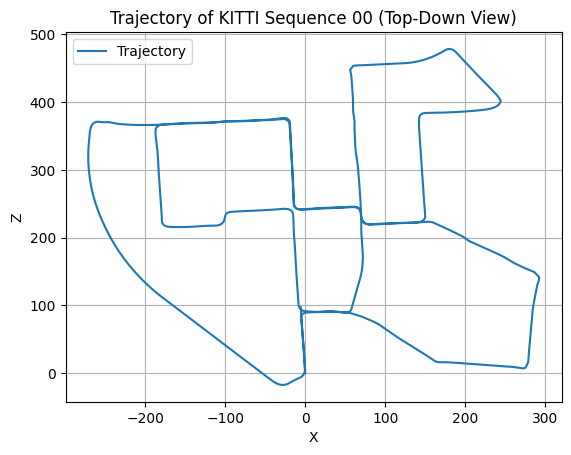

In [7]:
import matplotlib.pyplot as plt
import pykitti

# Path to KITTI odometry data
odometry_basedir = 'D:\\Research\\Dataset\\KITTI_odometry\\data_odometry_velodyne\\dataset'

# Specify the dataset to load
sequence = '00'  # Use sequence '00' for full trajectory

# Load the full dataset
dataset = pykitti.odometry(odometry_basedir, sequence)

# Extract poses
poses = dataset.poses

# Prepare arrays for x and z coordinates (for a top-down 2D view)
x_coords = []
z_coords = []

# Extract the trajectory points from poses
for pose in poses:
    x_coords.append(pose[0, 3])  # X coordinate
    z_coords.append(pose[2, 3])  # Z coordinate

# Plot the trajectory in 2D
plt.figure()
plt.plot(x_coords, z_coords, label="Trajectory")
plt.xlabel('X')
plt.ylabel('Z')
plt.title(f'Trajectory of KITTI Sequence {sequence} (Top-Down View)')
plt.legend()
plt.grid(True)

plt.show()


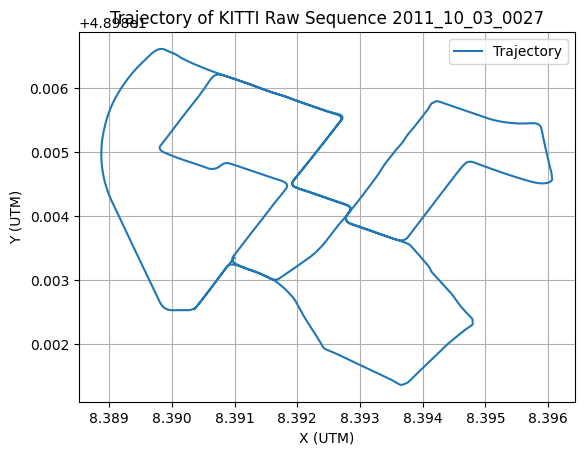

In [10]:
import pykitti
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
from pyproj import Transformer
from scipy.spatial import ConvexHull
from shapely.geometry import Polygon

# Set up KITTI raw data path and dataset details
basedir = 'D:\\Research\\Dataset\\kitti_raw'
date = '2011_10_03'
drive = '0027'

# Load the KITTI raw dataset
dataset = pykitti.raw(basedir, date, drive)

# Prepare lists to hold latitude and longitude coordinates
latitudes = []
longitudes = []

# Extract GPS data for each frame
for oxts in dataset.oxts:
    latitudes.append(oxts.packet.lat)
    longitudes.append(oxts.packet.lon)

# Convert latitude and longitude to UTM (or any other desired projection)
# transformer = Transformer.from_crs("epsg:4326", "epsg:32632")  # Example: UTM zone 32N
# x_coords, y_coords = transformer.transform(latitudes, longitudes)

# Plot the trajectory
plt.figure()
plt.plot(longitudes, latitudes, label="Trajectory")
plt.xlabel("X (UTM)")
plt.ylabel("Y (UTM)")
plt.title(f"Trajectory of KITTI Raw Sequence {date}_{drive}")
plt.legend()
plt.grid(True)
plt.show()


5.551115e-17 -4.440892e-16


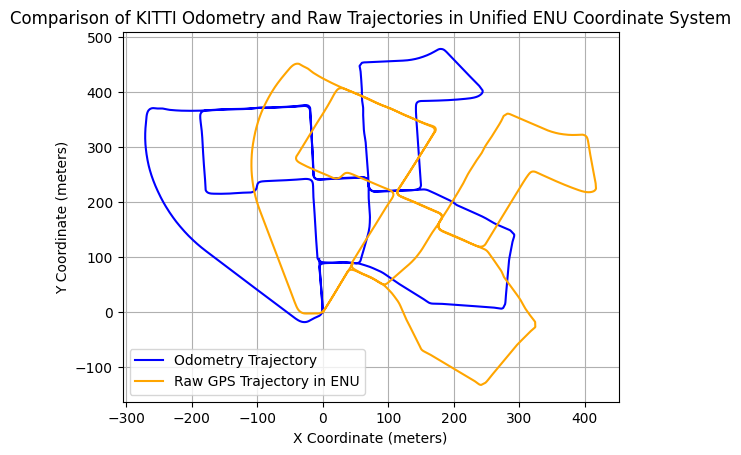

In [11]:
import pykitti
import numpy as np
import matplotlib.pyplot as plt
from pyproj import Proj, transform
from ori_geo import TopocentricConverter


# Set up paths and dataset details for both odometry and raw data
odometry_basedir = 'D:\\Research\\Dataset\\KITTI_odometry\\data_odometry_velodyne\\dataset'
raw_basedir = 'D:\\Research\\Dataset\\kitti_raw'
sequence = '00'  # Odometry sequence
date = '2011_10_03'  # Raw data date
drive = '0027'       # Raw data drive

# Load the KITTI odometry dataset
odometry_dataset = pykitti.odometry(odometry_basedir, sequence)

# Extract odometry trajectory
odometry_x = []
odometry_z = []

for pose in odometry_dataset.poses:
    odometry_x.append(pose[0, 3])  # X coordinate
    odometry_z.append(pose[2, 3])  # Z coordinate

print(odometry_dataset.poses[0][0, 3], odometry_dataset.poses[0][2, 3])
# Load the KITTI raw dataset
raw_dataset = pykitti.raw(raw_basedir, date, drive)

# Prepare lists to hold latitude and longitude coordinates
raw_latitudes = []
raw_longitudes = []

# Extract GPS data for each frame in the raw dataset
for oxts in raw_dataset.oxts:
    raw_latitudes.append(oxts.packet.lat)
    raw_longitudes.append(oxts.packet.lon)

lat, lon, alt = raw_dataset.oxts[0].packet.lat, raw_dataset.oxts[0].packet.lon, 0
converter = TopocentricConverter(lat, lon, alt)
# Convert the raw GPS data to ENU coordinates based on the first GPS point as the origin
origin_lat = raw_latitudes[0]
origin_lon = raw_longitudes[0]

# Define a projection for the local ENU system based on the origin
# proj_lla = Proj(proj="latlong", datum="WGS84")
# proj_enu = Proj(proj="utm", zone=32, datum="WGS84")  # UTM projection for ENU

# Transform the origin point to ENU
# origin_x, origin_y = transform(proj_lla, proj_enu, origin_lon, origin_lat)

# Transform all other points to ENU and offset by the origin
raw_x = []
raw_y = []

for lat, lon in zip(raw_latitudes, raw_longitudes):
    # x, y = transform(proj_lla, proj_enu, lon, lat)
    xy = converter.to_topocentric(lat, lon, 0.)[:2]
    # print(xy)
    raw_x.append(xy[0])  # Offset by origin
    raw_y.append(xy[1])

# Plot both trajectories on the same figure
plt.figure()
plt.plot(odometry_x, odometry_z, label="Odometry Trajectory", color='blue')
plt.plot(raw_x, raw_y, label="Raw GPS Trajectory in ENU", color='orange')
plt.xlabel("X Coordinate (meters)")
plt.ylabel("Y Coordinate (meters)")
plt.title("Comparison of KITTI Odometry and Raw Trajectories in Unified ENU Coordinate System")
plt.legend()
plt.grid(True)
plt.show()


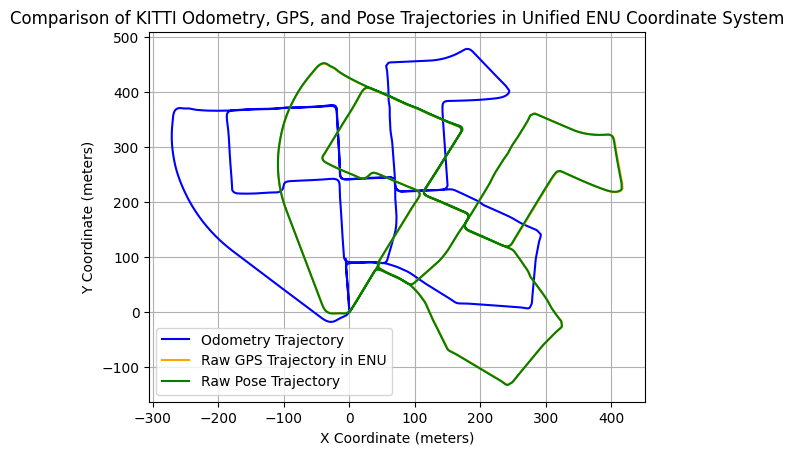

In [30]:
import pykitti
import numpy as np
import matplotlib.pyplot as plt
from ori_geo import TopocentricConverter

# Set up paths and dataset details for both odometry and raw data
odometry_basedir = 'D:\\Research\\Dataset\\KITTI_odometry\\data_odometry_velodyne\\dataset'
raw_basedir = 'D:\\Research\\Dataset\\kitti_raw'
sequence = '00'  # Odometry sequence
# sequence = '01'  # Odometry sequence
# sequence = '02'  # Odometry sequence
date = '2011_10_03'  # Raw data date
drive = '0027'       # Raw data drive
# drive = '0042'       # Raw data drive
# drive = '0034'       # Raw data drive
# Load the KITTI odometry dataset
odometry_dataset = pykitti.odometry(odometry_basedir, sequence)

# Extract odometry trajectory
odometry_x = []
odometry_z = []

for pose in odometry_dataset.poses:
    odometry_x.append(pose[0, 3])  # X coordinate
    odometry_z.append(pose[2, 3])  # Z coordinate

# Load the KITTI raw dataset
raw_dataset = pykitti.raw(raw_basedir, date, drive)

# Prepare lists to hold latitude and longitude coordinates for GPS
raw_latitudes = []
raw_longitudes = []
raw_altitudes = []
# Extract GPS data for each frame in the raw dataset
for oxts in raw_dataset.oxts:
    raw_latitudes.append(oxts.packet.lat)
    raw_longitudes.append(oxts.packet.lon)
    raw_altitudes.append(oxts.packet.alt)

# Initialize the topocentric converter based on the first GPS point in the raw dataset
lat, lon, alt = raw_dataset.oxts[0].packet.lat, raw_dataset.oxts[0].packet.lon, raw_dataset.oxts[0].packet.alt
converter = TopocentricConverter(lat, lon, alt)

# Convert raw GPS data to ENU coordinates
raw_x = []
raw_y = []

for lat, lon, alt in zip(raw_latitudes, raw_longitudes, raw_altitudes):
    xy = converter.to_topocentric(lat, lon, alt)[:2]
    raw_x.append(xy[0])
    raw_y.append(xy[1])

# Extract pose trajectory from KITTI raw dataset
raw_pose_x = []
raw_pose_y = []

for oxts in raw_dataset.oxts:
    pose = oxts.T_w_imu  # Transformation matrix from IMU to world coordinates
    pose = np.dot(pose, np.linalg.inv(raw_dataset.calib.T_cam0_imu)) # Transform to camera coordinates
    raw_pose_x.append(pose[0, 3])  # X coordinate
    raw_pose_y.append(pose[1, 3])  # Y coordinate
    # print(pose[0, 3], pose[1, 3])
# Plot all three trajectories on the same figure
plt.figure()
plt.plot(odometry_x, odometry_z, label="Odometry Trajectory", color='blue')
plt.plot(raw_x, raw_y, label="Raw GPS Trajectory in ENU", color='orange')
plt.plot(raw_pose_x, raw_pose_y, label="Raw Pose Trajectory", color='green')
plt.xlabel("X Coordinate (meters)")
plt.ylabel("Y Coordinate (meters)")
plt.title("Comparison of KITTI Odometry, GPS, and Pose Trajectories in Unified ENU Coordinate System")
plt.legend()
plt.grid(True)
plt.show()


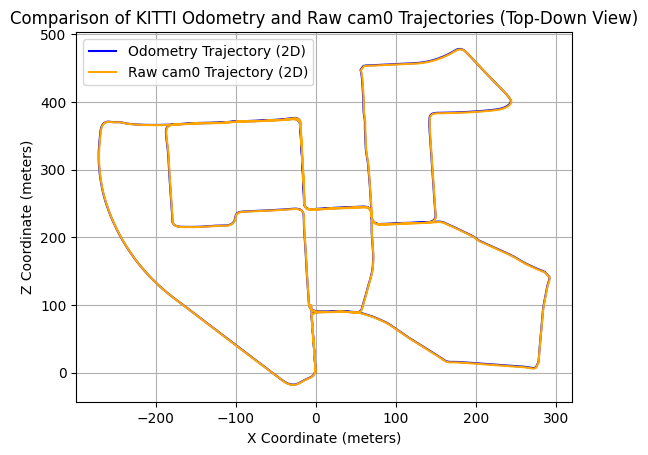

In [30]:
import numpy as np
import matplotlib.pyplot as plt
import pykitti

# Set up paths and dataset details for both odometry and raw data
odometry_basedir = 'D:\\Research\\Dataset\\KITTI_odometry\\data_odometry_velodyne\\dataset'
raw_basedir = 'D:\\Research\\Dataset\\kitti_raw'
sequence = '00'  # Odometry sequence
date = '2011_10_03'  # Raw data date
drive = '0027'       # Raw data drive

# Load the KITTI odometry dataset
odometry_dataset = pykitti.odometry(odometry_basedir, sequence)

# Extract odometry trajectory in the X-Z plane (2D view)
odometry_x = []
odometry_z = []

for pose in odometry_dataset.poses:
    odometry_x.append(pose[0, 3])  # X coordinate
    odometry_z.append(pose[2, 3])  # Z coordinate

# Load the KITTI raw dataset
raw_dataset = pykitti.raw(raw_basedir, date, drive)

# Load transformations
T_cam0_imu = raw_dataset.calib.T_cam0_imu  # Transformation from IMU to cam0
T_w_imu = [oxts.T_w_imu for oxts in raw_dataset.oxts]  # Transformation from IMU to world for each frame

# Compute the transformation from world to the first cam0 frame
T_w_cam0_0 = T_w_imu[0] @ np.linalg.inv(T_cam0_imu)
T_cam0_0_world = np.linalg.inv(T_w_cam0_0)

# Initialize lists for storing raw cam0 trajectory points in the X-Z plane
cam0_x = []
cam0_z = []

# Calculate the position of each cam0 frame relative to the first cam0 frame
for T_w_imu_i in T_w_imu:
    T_w_cam0_i = T_w_imu_i @ np.linalg.inv(T_cam0_imu)
    T_cam0_0_cam0_i = T_cam0_0_world @ T_w_cam0_i
    position = T_cam0_0_cam0_i[:3, 3]  # Extract the translation vector (x, y, z)

    # Append the position to the cam0 trajectory lists (only x and z for 2D plot)
    cam0_x.append(position[0])
    cam0_z.append(position[2])

# Plot both trajectories on the same 2D figure
plt.figure()
plt.plot(odometry_x, odometry_z, label="Odometry Trajectory (2D)", color='blue')
plt.plot(cam0_x, cam0_z, label="Raw cam0 Trajectory (2D)", color='orange')
plt.xlabel("X Coordinate (meters)")
plt.ylabel("Z Coordinate (meters)")
plt.title("Comparison of KITTI Odometry and Raw cam0 Trajectories (Top-Down View)")
plt.legend()
plt.grid(True)
plt.show()


## Alignment of KITTI Odometry with OSM

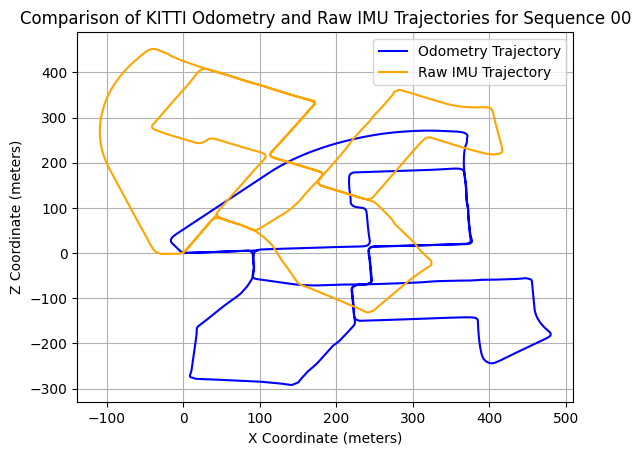

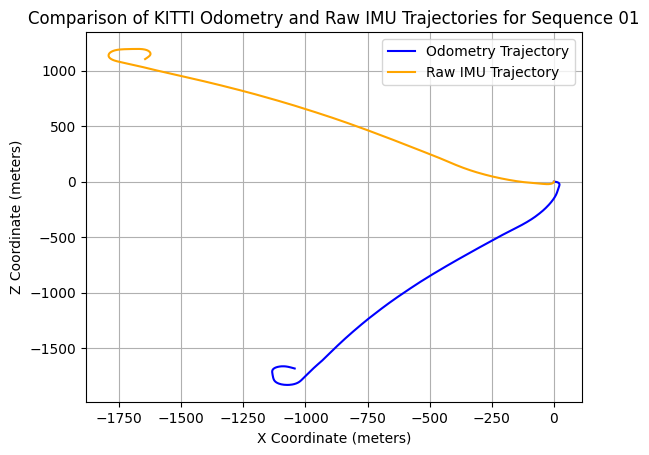

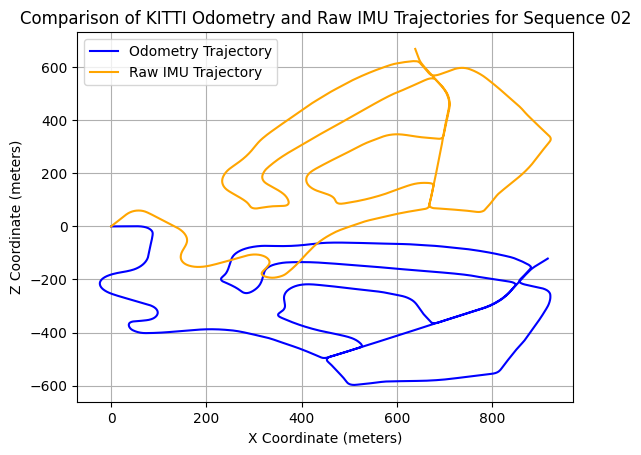

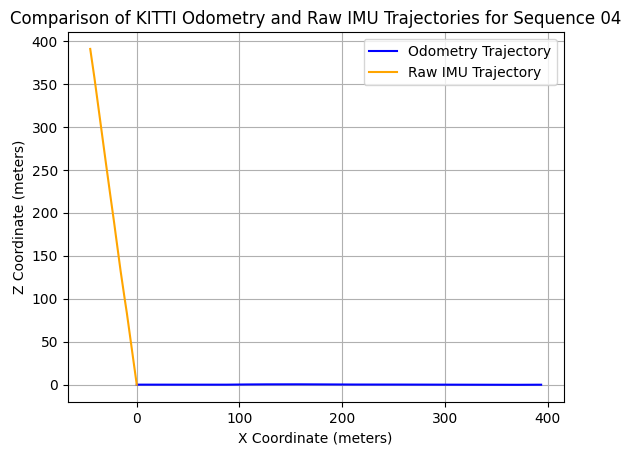

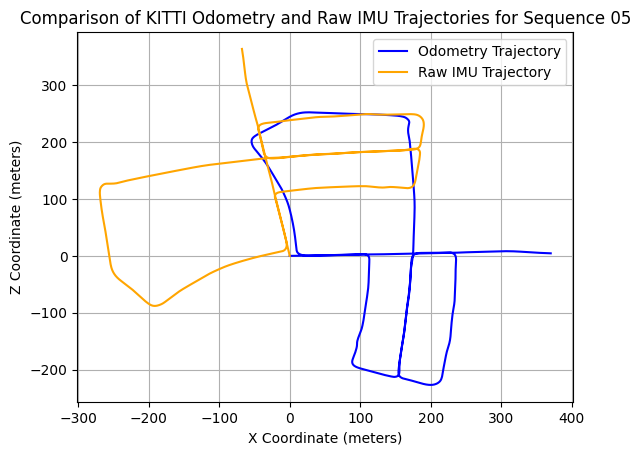

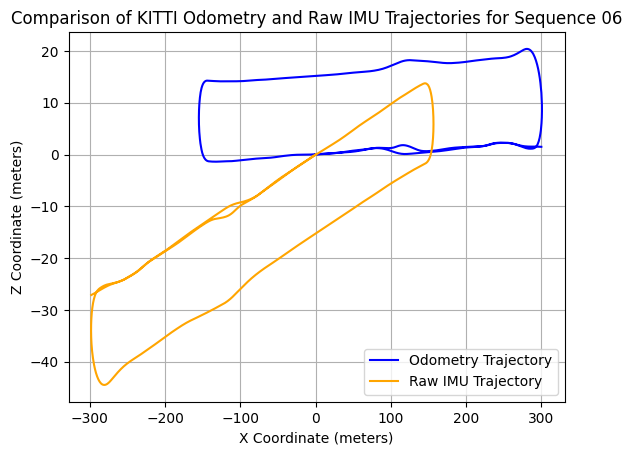

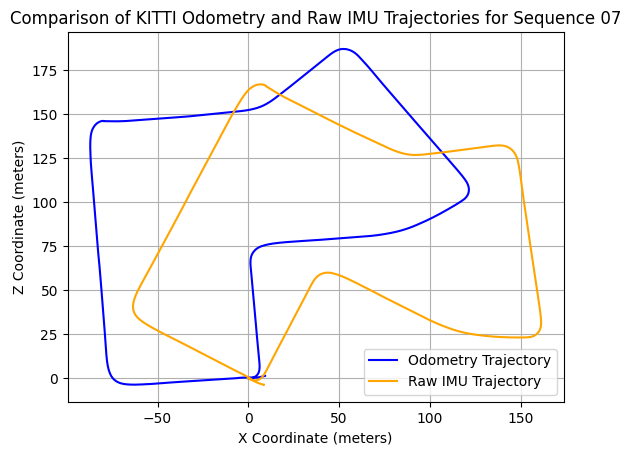

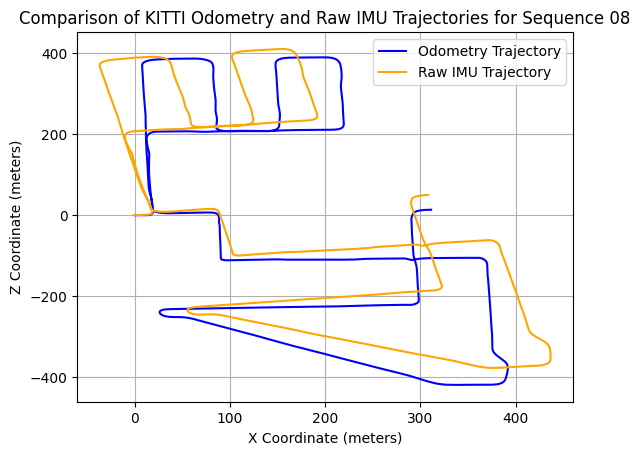

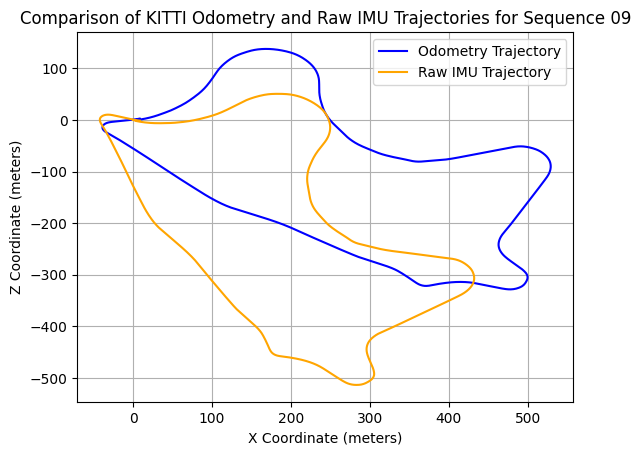

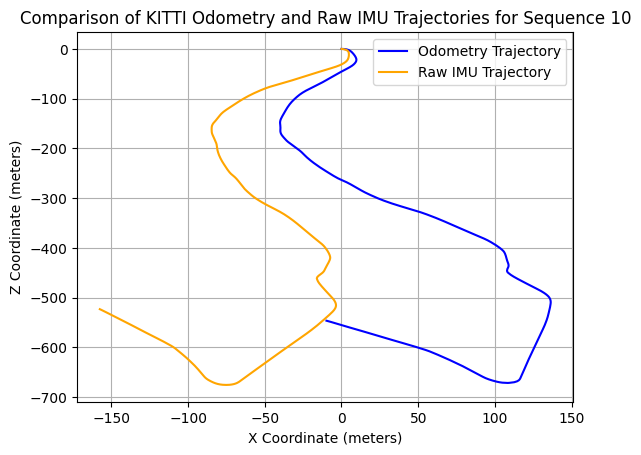

In [33]:
import pykitti 
import numpy as np
import matplotlib.pyplot as plt
from ori_geo import TopocentricConverter
# Define the data as a dictionary with the required format
kitti_sequences = {
    "00": {"date": "2011_10_03", "drive": "0027", "start": 0, "end": 4540},
    "01": {"date": "2011_10_03", "drive": "0042", "start": 0, "end": 1100},
    "02": {"date": "2011_10_03", "drive": "0034", "start": 0, "end": 4660},
    "04": {"date": "2011_09_30", "drive": "0016", "start": 0, "end": 270},
    "05": {"date": "2011_09_30", "drive": "0018", "start": 0, "end": 2760},
    "06": {"date": "2011_09_30", "drive": "0020", "start": 0, "end": 1100},
    "07": {"date": "2011_09_30", "drive": "0027", "start": 0, "end": 1100},
    "08": {"date": "2011_09_30", "drive": "0028", "start": 1100, "end": 5170},
    "09": {"date": "2011_09_30", "drive": "0033", "start": 0, "end": 1590},
    "10": {"date": "2011_09_30", "drive": "0034", "start": 0, "end": 1200}
}

# Load the raw and odometry dataset
odometry_basedir = 'D:\\Research\\Dataset\\KITTI_odometry\\data_odometry_velodyne\\dataset'
raw_basedir = 'D:\\Research\\Dataset\\kitti_raw'

for sequence in kitti_sequences.keys():
    date = kitti_sequences[sequence]["date"]
    drive = kitti_sequences[sequence]["drive"]
    start = kitti_sequences[sequence]["start"]
    end = kitti_sequences[sequence]["end"]

    # Load datasets
    odometry_dataset = pykitti.odometry(odometry_basedir, sequence)
    raw_dataset = pykitti.raw(raw_basedir, date, drive, frames=range(start, end+1))
    # print(odometry_dataset.__len__(), raw_dataset.__len__())
    # Extract odometry trajectory
    odometry_x = []
    odometry_z = []
    
    # obtain T_imu_0_imu_i from T_cam0_0_cam0_i
    T_cam0_imu = raw_dataset.calib.T_cam0_imu
    T_imu_cam0 = np.linalg.inv(raw_dataset.calib.T_cam0_imu)
    T_w_imu = [oxts.T_w_imu for oxts in raw_dataset.oxts]
    # T_imu_imu0 = [np.linalg.inv(T_w_imu_i) for T_w_imu_i in T_w_imu]
    for i, pose in enumerate(odometry_dataset.poses):
        T_cam0_0_cam0 = pose 
        T_cam0_0_imu = np.dot(T_cam0_0_cam0, T_cam0_imu)
        T_imu_imu_i = np.dot(T_imu_cam0, T_cam0_0_imu)
        # pose_to_world = np.dot(T_w_imu[i], T_imu_imu_i)
        odometry_x.append(T_imu_imu_i[0, 3])
        odometry_z.append(T_imu_imu_i[1, 3])

    # Prepare lists to hold latitude and longitude coordinates for GPS
    raw_latitudes = []
    raw_longitudes = []
    raw_altitudes = []
    # Extract GPS data for each frame in the raw dataseta
    for oxts in raw_dataset.oxts:
        raw_latitudes.append(oxts.packet.lat)
        raw_longitudes.append(oxts.packet.lon)
        raw_altitudes.append(oxts.packet.alt)

    # Initialize the topocentric converter based on the first GPS point in the raw dataset
    lat, lon, alt = raw_dataset.oxts[0].packet.lat, raw_dataset.oxts[0].packet.lon, raw_dataset.oxts[0].packet.alt
    converter = TopocentricConverter(lat, lon, alt)

    # Convert raw GPS data to ENU coordinates
    raw_x = []
    raw_y = []

    for lat, lon, alt in zip(raw_latitudes, raw_longitudes, raw_altitudes):
        xy = converter.to_topocentric(lat, lon, alt)[:2]
        raw_x.append(xy[0])
        raw_y.append(xy[1])

    # for i in range(len(raw_x)):
    #     print(raw_x[i], raw_y[i], odometry_x[i], odometry_z[i])
    # Plot the trajectories
    plt.figure()
    plt.plot(odometry_x, odometry_z, label="Odometry Trajectory", color='blue')
    plt.plot(raw_x, raw_y, label="Raw IMU Trajectory", color='orange')
    plt.xlabel("X Coordinate (meters)")
    plt.ylabel("Z Coordinate (meters)")
    plt.title(f"Comparison of KITTI Odometry and Raw IMU Trajectories for Sequence {sequence}")
    plt.legend()
    plt.grid(True)
    plt.show()


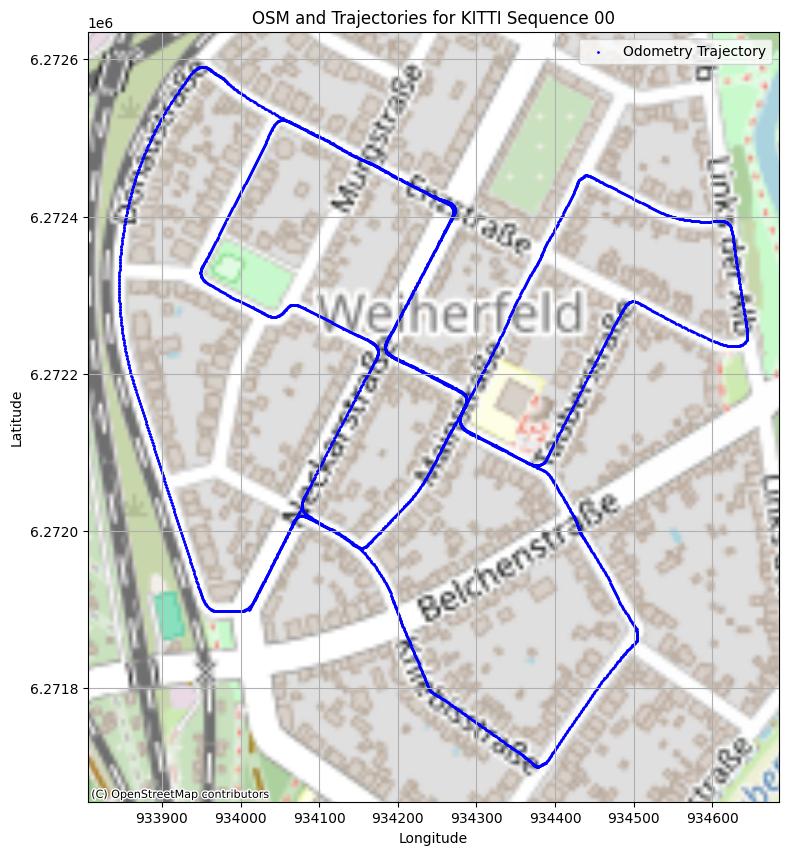

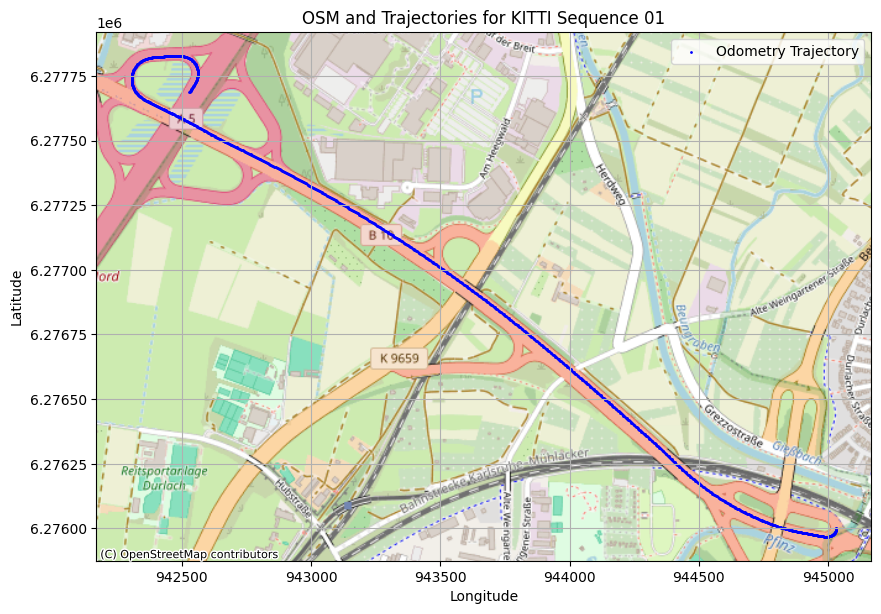

In [39]:
import pykitti
import numpy as np
import matplotlib.pyplot as plt
import contextily as ctx
from ori_geo import TopocentricConverter
from shapely.geometry import Point
import geopandas as gpd

# Define the data as a dictionary with the required format
kitti_sequences = {
    "00": {"date": "2011_10_03", "drive": "0027", "start": 0, "end": 4540},
    "01": {"date": "2011_10_03", "drive": "0042", "start": 0, "end": 1100},
    "02": {"date": "2011_10_03", "drive": "0034", "start": 0, "end": 4660},
    "04": {"date": "2011_09_30", "drive": "0016", "start": 0, "end": 270},
    "05": {"date": "2011_09_30", "drive": "0018", "start": 0, "end": 2760},
    "06": {"date": "2011_09_30", "drive": "0020", "start": 0, "end": 1100},
    "07": {"date": "2011_09_30", "drive": "0027", "start": 0, "end": 1100},
    "08": {"date": "2011_09_30", "drive": "0028", "start": 1100, "end": 5170},
    "09": {"date": "2011_09_30", "drive": "0033", "start": 0, "end": 1590},
    "10": {"date": "2011_09_30", "drive": "0034", "start": 0, "end": 1200}
}

# Load the raw and odometry dataset
odometry_basedir = 'D:\\Research\\Dataset\\KITTI_odometry\\data_odometry_velodyne\\dataset'
raw_basedir = 'D:\\Research\\Dataset\\kitti_raw'

for sequence in kitti_sequences.keys():
    date = kitti_sequences[sequence]["date"]
    drive = kitti_sequences[sequence]["drive"]
    start = kitti_sequences[sequence]["start"]
    end = kitti_sequences[sequence]["end"]

    # Load datasets
    odometry_dataset = pykitti.odometry(odometry_basedir, sequence)
    raw_dataset = pykitti.raw(raw_basedir, date, drive, frames=range(start, end+1))

    
    # Extract odometry trajectory
    odometry_x = []
    odometry_y = []
    odometry_z = []

    T_cam0_imu = raw_dataset.calib.T_cam0_imu
    T_imu_cam0 = np.linalg.inv(T_cam0_imu)
    T_w_imu_0 = raw_dataset.oxts[0].T_w_imu  # 初始帧的 T_w_imu_0
    for i, pose in enumerate(odometry_dataset.poses):
        T_cam0_0_imu = np.dot(pose, T_cam0_imu)
        # T_cam0_0_imu_i -> T_w_imu_i (apply initial frame's world to imu transform)
        T_w_imu_i = np.dot(T_w_imu_0, np.dot(T_imu_cam0, T_cam0_0_imu))
        odometry_x.append(T_w_imu_i[0, 3])
        odometry_y.append(T_w_imu_i[1, 3])
        odometry_z.append(T_w_imu_i[2, 3])

    # Prepare lists to hold latitude and longitude coordinates for GPS
    raw_latitudes = []
    raw_longitudes = []
    raw_altitudes = []
    # Extract GPS data for each frame in the raw dataset
    for oxts in raw_dataset.oxts:
        raw_latitudes.append(oxts.packet.lat)
        raw_longitudes.append(oxts.packet.lon)
        raw_altitudes.append(oxts.packet.alt)

    # Initialize the topocentric converter based on the first GPS point in the raw dataset
    lat, lon, alt = raw_dataset.oxts[0].packet.lat, raw_dataset.oxts[0].packet.lon, raw_dataset.oxts[0].packet.alt
    converter = TopocentricConverter(lat, lon, alt)

    odo_alt_list = []
    odo_lat_list = []
    odo_lon_list = []
    for x, y, z in zip(odometry_x, odometry_y, odometry_z):
        odo_lat, odo_lon, odo_alt = converter.to_lla(x, y, z)
        odo_lat_list.append(odo_lat)
        odo_lon_list.append(odo_lon)
        odo_alt_list.append(odo_alt)

    # Convert raw GPS data to ENU coordinates
    raw_x = []
    raw_y = []
    raw_z = []
    # odo_alt_list = []
    # odo_lat_list = []
    # odo_lon_list = []

    for lat, lon, alt in zip(raw_latitudes, raw_longitudes, raw_altitudes):
        xy = converter.to_topocentric(lat, lon, alt)
        raw_x.append(xy[0])
        raw_y.append(xy[1])
        raw_z.append(xy[2])
        # odo_lat, odo_lon, odo_alt = converter.to_lla(xy[0], xy[1], xy[2])
        # odo_lat_list.append(odo_lat)
        # odo_lon_list.append(odo_lon)
        # odo_alt_list.append(odo_alt)
        # print(lat, lon, alt, odo_lat, odo_lon, odo_alt)
    # Convert GPS coordinates to GeoDataFrame for OSM overlay
    gdf = gpd.GeoDataFrame(geometry=[Point(lon, lat) for lon, lat in zip(raw_longitudes, raw_latitudes)], crs="EPSG:4326")
    gdf = gdf.to_crs(epsg=3857)  # Convert to Web Mercator for contextily

    gdf_odo = gpd.GeoDataFrame(geometry=[Point(lon, lat) for lon, lat in zip(odo_lon_list, odo_lat_list)], crs="EPSG:4326")
    gdf_odo = gdf_odo.to_crs(epsg=3857)  # Convert to Web Mercator for contextily

    # Plot the trajectories on the OSM map
    fig, ax = plt.subplots(figsize=(10, 10))
    # gdf.plot(ax=ax, color="red", label="Raw IMU Trajectory (GPS-based)", markersize=1)
    gdf_odo.plot(ax=ax, color="blue", label="Odometry Trajectory", markersize=1)
    # Overlay the OSM basemap
    minx, miny, maxx, maxy = gdf.total_bounds
    ctx.add_basemap(ax, crs=gdf.crs.to_string(), zoom=15, source=ctx.providers.OpenStreetMap.Mapnik)
    
    # Plot the odometry trajectory on top
    # plt.plot(odometry_x, odometry_z, label="Odometry Trajectory", color='blue', linewidth=2)

    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.title(f"OSM and Trajectories for KITTI Sequence {sequence}")
    plt.legend()
    plt.grid(True)

    # Save plot as PNG
    plt.savefig(f"pics/trajectory_{sequence}.png", dpi=600)
    plt.show()
